<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/NBC%2CKNN%26DecissionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Load the dataset
df = pd.read_csv("//content//Global_Pollution_Analysis (1).csv")

# Display the first few rows
df.head()


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [ ]:
# Check for missing values
print(df.isnull().sum())

# Fill numeric missing values with mean
num_imputer = SimpleImputer(strategy='mean')
df[df.select_dtypes(include=['float64', 'int64']).columns] = num_imputer.fit_transform(
    df.select_dtypes(include=['float64', 'int64'])
)

# Fill categorical missing values with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[df.select_dtypes(include=['object']).columns] = cat_imputer.fit_transform(
    df.select_dtypes(include=['object'])
)

# Outlier handling (example: Z-score method on CO2 emissions)
from scipy.stats import zscore
df['CO2_Emissions_Z'] = zscore(df['CO2_Emissions (in MT)'])
df = df[df['CO2_Emissions_Z'].abs() < 3]  # Keep only non-outliers
df.drop('CO2_Emissions_Z', axis=1, inplace=True)

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64


In [ ]:
# Label encoding for categorical variables
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])
df['Year'] = le.fit_transform(df['Year'])

# Standardize numerical features
scaler = StandardScaler()
numerical_cols = ['CO2_Emissions (in MT)', 'Industrial_Waste (in tons)', 'Air_Pollution_Index',
                  'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Consumption_Per_Capita (in MWh)']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [ ]:
# Example: Energy consumption per capita
df['Energy_Per_Capita'] = df['Energy_Consumption_Per_Capita (in MWh)'] / df['Population (in millions)']

# Example: Pollution index average
df['Pollution_Severity'] = df[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean(axis=1)

# Bin Pollution Severity into classes (Low, Medium, High)
df['Pollution_Label'] = pd.cut(df['Pollution_Severity'],
                               bins=[-np.inf, 0.4, 0.7, np.inf],
                               labels=['Low', 'Medium', 'High'])

In [ ]:
# Phase 2 - Classification
features = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
            'Industrial_Waste (in tons)', 'Energy_Per_Capita', 'CO2_Emissions (in MT)']
X = df[features]
y = df['Pollution_Label']
y_encoded = LabelEncoder().fit_transform(y)

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
# Naive Bayes with MinMax scaling
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB

X_nb_scaled = MinMaxScaler().fit_transform(X)
X_nb_train, X_nb_test, y_nb_train, y_nb_test = train_test_split(X_nb_scaled, y_encoded, test_size=0.2, random_state=42)
nb_model = MultinomialNB()
nb_model.fit(X_nb_train, y_nb_train)
y_pred_nb = nb_model.predict(X_nb_test)

In [ ]:
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Results")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))


In [ ]:
evaluate_model("Naive Bayes", y_nb_test, y_pred_nb)
evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn)
evaluate_model("Decision Tree", y_test, y_pred_dt)



Naive Bayes Results
Accuracy: 0.825
Confusion Matrix:
 [[ 0  5  0]
 [ 0 33  0]
 [ 0  2  0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.82      1.00      0.90        33
           2       0.00      0.00      0.00         2

    accuracy                           0.82        40
   macro avg       0.27      0.33      0.30        40
weighted avg       0.68      0.82      0.75        40


K-Nearest Neighbors Results
Accuracy: 0.85
Confusion Matrix:
 [[ 2  1  2]
 [ 0 31  2]
 [ 0  1  1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.94      0.94      0.94        33
           2       0.20      0.50      0.29         2

    accuracy                           0.85        40
   macro avg       0.71      0.61      0.60        40
weighted avg       0.91      0.85      0.86        4

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Optional: Plot confusion matrix for each model
def plot_conf_matrix(cm, title):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


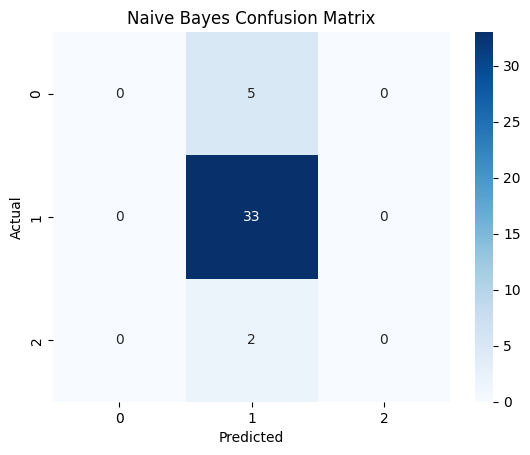

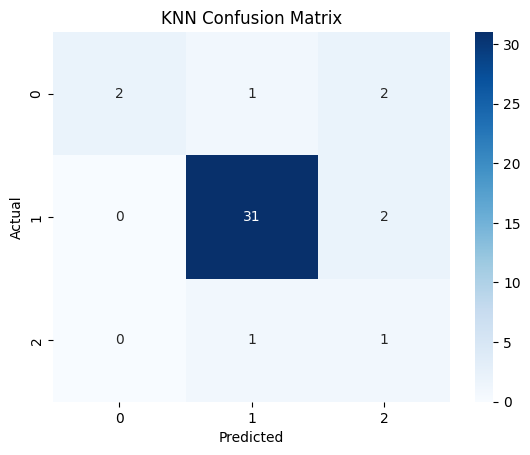

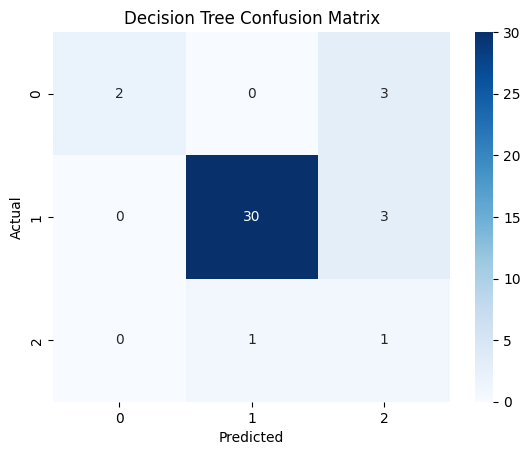

In [ ]:
plot_conf_matrix(confusion_matrix(y_nb_test, y_pred_nb), "Naive Bayes Confusion Matrix")
plot_conf_matrix(confusion_matrix(y_test, y_pred_knn), "KNN Confusion Matrix")
plot_conf_matrix(confusion_matrix(y_test, y_pred_dt), "Decision Tree Confusion Matrix")
